In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

ROOT = Path("..")

In [27]:
funding = pd.read_csv(ROOT / "data/processed/funding_BTC.csv")

funding.head()


,exchange,asset,symbol,timestamp,funding_rate,interval_hours,mark_price
0,kraken,BTC,PF_XBTUSD,2025-06-10T14:00:00Z,0.000013,1,NaN
1,kraken,BTC,PF_XBTUSD,2025-06-10T15:00:00Z,0.000005,1,NaN
2,kraken,BTC,PF_XBTUSD,2025-06-10T16:00:00Z,0.000002,1,NaN
3,kraken,BTC,PF_XBTUSD,2025-06-10T17:00:00Z,0.000005,1,NaN
4,kraken,BTC,PF_XBTUSD,2025-06-10T18:00:00Z,0.000004,1,NaN


In [19]:
rows = json.loads((ROOT / "data/raw/funding/kraken_BTC.json").read_text())

In [23]:
funding.head()

,fundingRate,relativeFundingRate,timestamp
0,1.375120,0.000013,2025-06-10T14:00:00Z
1,0.551916,0.000005,2025-06-10T15:00:00Z
2,0.268110,0.000002,2025-06-10T16:00:00Z
3,0.571015,0.000005,2025-06-10T17:00:00Z
4,0.432380,0.000004,2025-06-10T18:00:00Z


In [22]:
#rows = json.loads((ROOT / "data/raw/funding/binance_BTC.json").read_text())

funding = pd.DataFrame(rows['rates'])
funding["timestamp"] = pd.to_datetime(funding["fundingTime"], unit="ms",utc=True)
funding["fundingRate"] = funding['fundingRate'].astype(float)
funding["markPrice"] = funding['markPrice'].astype(float)

funding = funding.sort_values("timestamp")
funding.head()

KeyError: 'fundingTime'

In [9]:
funding[["timestamp","fundingRate","markPrice"]].describe()


,fundingRate,markPrice
count,1095.000000,1095.000000
mean,0.000032,92597.805932
std,0.000048,18768.342435
min,-0.000152,60416.492109
25%,0.000002,75160.373975
50%,0.000036,90604.038808
75%,0.000069,110905.866844
max,0.000100,124946.200000


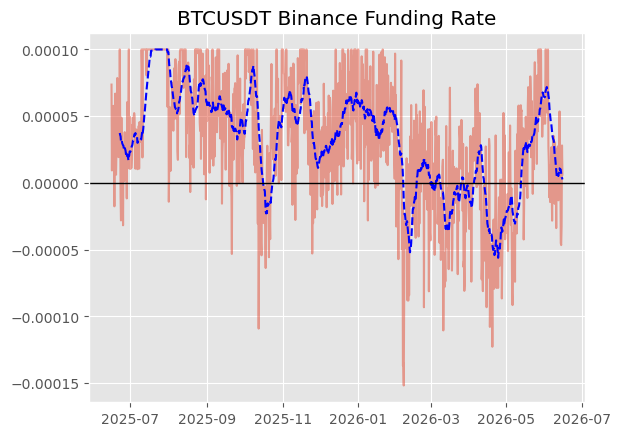

In [14]:
window = 21

funding["fundingRate_ma"] = funding["fundingRate"].rolling(window).mean()

plt.title("BTCUSDT Binance Funding Rate")
plt.plot(funding['timestamp'],funding['fundingRate'],alpha = 0.5)
plt.plot(funding['timestamp'],funding['fundingRate_ma'], color='blue', linestyle='--')
plt.axhline(0,color = "black",linewidth=1)
plt.show()
#plt.plot(funding['timestamp'],funding['fundingRate'])

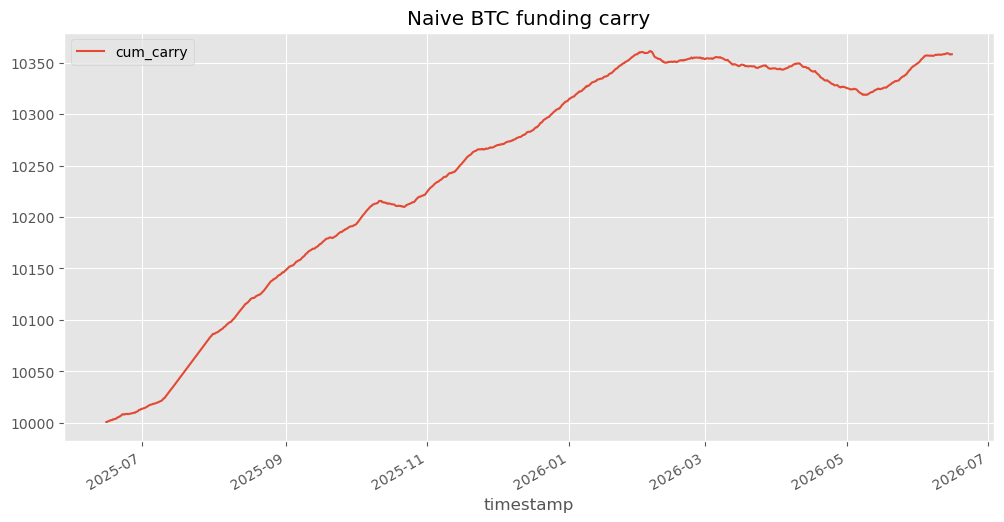

In [18]:
#naive carry PnL
notional = 10_000
funding["carryPnL"] = funding["fundingRate"]
funding["cum_carry"] = (1+funding["carryPnL"]).cumprod() * notional

funding.plot(x = 'timestamp', y = 'cum_carry', figsize = (12,6), title = "Naive BTC funding carry")
plt.show()

In [17]:
# let's assume we pay 10bps cost to enter and exit

cost = 0.001  # 10bps
net_total_return = funding["cum_carry"].iloc[-1] - cost
net_total_return

0.03483079702479086

In [ ]:
# let's test a simple momentum strategy
df["prev_funding_ma"] = df["funding_ma"].shift(window)

df["raw_signal"] = (
    (df["funding_ma"] > df["prev_funidng"])
)
